# Trishuli 2026 — Model Workings

[Project home](index.html) · [Plain English](plain.html) ·
[Technical report](report.html) · **Model workings** ·
[source and revision history on GitHub](https://github.com/djhume/nepal-flood-2026)

**What this is.** The executable workings behind our analysis of the 26 August 2026
Langtang Lirung ice-rock avalanche → Lhende Khola / Bhote Koshi / Trishuli flood:
where the water came from, and how the flood pulse evolved over ~200 km of
channel. Five model stages run top to bottom, in the order they were built:

1. **Energy & water budget** — independent bounds on each candidate water source
   (frictional ice melt vs river-derived water), validated against Chamoli 2021.
2. **Snowplow-integral model** — 1D front-routing along the DEM river profile with
   per-source water bookkeeping, calibrated to the observed arrival clocks.
3. **Ladder network** — a 90-node routing model as a nonlinear R(L)C
   transmission line (diffusive-wave v0, upgraded to the local-inertia RLC form)
   for pulse structure: attenuation, side-valley charging, and the signature a
   temporary dam breach would leave.
4. **Entrainment, and the falsification of the single-phase model** — the erosion
   term the first three stages lacked, the rejection sampling that then proved
   the model form wrong, and the two-phase fix.
5. **The consistency envelope** — which combinations of release volume and
   composition are simultaneously consistent with everything measurable, giving
   14–34 Mm³.

**Dates.** Sections 1–3 are dated 2 September 2026 (event + 7 days), with all
inputs stamped to what was public then. Sections 4 and 5 were built on 3–5
September and added to this notebook on 5 September. Until then this page was
published three days behind the findings it was supposed to make checkable —
the summary pages announced results whose workings were not here. That was the
wrong way round, and the fix is this notebook rather than a footnote about it.

**Data files** (in `data/`):

- `river_profile.csv` — 499-point channel profile, collapse scar → Devghat
  (199.3 km), from an OSM-stitched river path with Mapzen terrain-tile elevations
  (built by `model/build_profile.py` + `model/fetch_elevations.py`)
- `valmikinagar_barrage.csv` — Gandak barrage hourly releases at the India border
  (press transcriptions), downstream routing context in the full report
- `ffd_report.pdf` — official DHM/FFD press release (27 Aug): station clocks,
  Devghat peak 5,850 m³/s at 16:00, and the "~20 Mm³ excess water" figure

**Authorship:** Dave Hume, with Claude as research and modelling assistant.

**Honesty rail.** The two most important inputs are *not published*: the source
volume (public estimates span 0.5–200 Mm³) and the ice fraction of the collapsed
mass (unknown). Every conclusion below is therefore an **envelope over defensible
inputs**, not a point claim. FFD's "~20 Mm³ excess" is single-source with an
unpublished method; geopera velocity/height numbers are provisional. Where the
models disagree with observation, we say so.

**The border clock in this notebook.** The border arrival is scored at 7.68 min
(7 min 40 s, read directly off the CCTV overlay on 6 September). Until late on
6 September this notebook — and every model constant — still carried 7.0 min
while the pages already said 7:40; that was caught in a third cold read and
fixed in six files, and the ensemble was rerun (13.3–34.0 Mm³, median 23.2,
21 of 200, against 14–34 / median 21 from the 7.0-min run). The speed panel in
Section 2 still plots the 52 m/s point under its original label ("Kargel,
193 km/h"); the corrected 22-km mean is 47.8 m/s, and the ensemble's speed
observable is geopera's 48.5 ± 35%, unchanged.

## 1. Energy & water budget

**The physics in one line: melt is energy-limited.** Melting ice takes latent heat
L_f = 334 kJ/kg. The only energy source is the fall itself: potential energy *mgh*
gives 9.81 J per kg per metre of drop. A parcel falling the ~1,200 m from the
Langtang Lirung scar to the channel carries ~12 kJ/kg — about 3.5% of what it would
take to melt its own mass of ice. Even over a full ~2,400–3,500 m drop, melting a
Chamoli-like ~8% ice mass fraction needs most of the dissipated heat to enter the
ice, and realistic heat-to-ice partitions in the literature are *tuned* (0.3–0.7),
not measured.

So we bound each candidate water source **independently**:

- **A. frictional melt** = min(energy cap, ice-mass cap)
- **B. standing river water** in the channel ahead of the wave (swept up)
- **C. river inflow** during the event's passage
- **D. pore water** in entrained saturated channel sediment

Code adapted from `calcs/energy_water_budget.py` — identical numbers.

In [1]:
G = 9.81          # m/s^2
LF = 3.34e5       # J/kg latent heat of fusion of ice
RHO_ROCK = 2700.0 # kg/m^3
RHO_ICE = 900.0   # kg/m^3
RHO_W = 1000.0    # kg/m^3

def scenario(name, V_total_Mm3, ice_frac, drop_total_m, heat_to_ice_frac,
             channel_km, Q_river, v_river, event_hours,
             sed_entrain_Mm3, sed_porosity, sed_saturation):
    V = V_total_Mm3 * 1e6
    V_ice, V_rock = V * ice_frac, V * (1 - ice_frac)
    m_ice, m_rock = V_ice * RHO_ICE, V_rock * RHO_ROCK
    m_total = m_ice + m_rock

    # --- A. frictional melt ---
    E_pot = m_total * G * drop_total_m           # J released over full runout
    E_to_melt = E_pot * heat_to_ice_frac         # share of heat that melts ice
    m_melt_energy_limited = E_to_melt / LF
    m_melt = min(m_melt_energy_limited, m_ice)   # can't melt more ice than exists
    W_melt = m_melt / RHO_W                      # m^3 of meltwater

    # --- B. standing water in channel (wave sweeps it all up) ---
    A_flow = Q_river / v_river                   # wetted cross-section, m^2
    W_channel = A_flow * channel_km * 1e3

    # --- C. inflow during event ---
    W_inflow = Q_river * event_hours * 3600

    # --- D. pore water in entrained sediment ---
    W_pore = sed_entrain_Mm3 * 1e6 * sed_porosity * sed_saturation

    W_total = W_melt + W_channel + W_inflow + W_pore
    print(f"\n=== {name} ===")
    print(f"  source volume {V_total_Mm3:.0f} Mm3, ice fraction {ice_frac:.0%},"
          f" total drop {drop_total_m:.0f} m")
    print(f"  potential energy released: {E_pot:.2e} J")
    print(f"  ice melt:   energy-limited {m_melt_energy_limited/RHO_W/1e6:6.1f} Mm3,"
          f" ice-limited {m_ice/RHO_W/1e6:6.1f} Mm3"
          f"  -> melt water {W_melt/1e6:6.1f} Mm3 ({W_melt/W_total:5.1%})")
    print(f"  channel standing water ({channel_km:.0f} km @ A={A_flow:.0f} m2):"
          f"       {W_channel/1e6:6.1f} Mm3 ({W_channel/W_total:5.1%})")
    print(f"  river inflow during {event_hours:.1f} h @ {Q_river:.0f} m3/s:"
          f"          {W_inflow/1e6:6.1f} Mm3 ({W_inflow/W_total:5.1%})")
    print(f"  sediment pore water:                        "
          f" {W_pore/1e6:6.1f} Mm3 ({W_pore/W_total:5.1%})")
    print(f"  TOTAL WATER: {W_total/1e6:.1f} Mm3"
          f"   | river-derived (B+C): {(W_channel+W_inflow)/W_total:.1%}")

### Validation: Chamoli 2021

Before pointing this at Nepal, the check. Shugar et al. (2021, *Science*)
reconstructed the Chamoli disaster as 26.9 Mm³ at ~80:20 rock:ice by volume,
falling ~3,400 m over a short 26 km winter runout, with near-complete melt of the
~5–6 Mm³ of ice; their energy balance implies ~80% of dissipated heat entered the
ice ("almost exactly the critical value required for near-complete melting").
River terms were near zero (winter low flow). The scenario function should
reproduce **~5 Mm³ of melt, hitting the ice-mass limit** rather than the energy
limit — Chamoli is the rare case with energy to spare.

In [2]:
# Validation: Chamoli 2021 (Shugar et al. 2021 Science). 26.9 Mm3, 80:20
# rock:ice by volume, ~3400 m drop, near-complete melt of ~5-6 Mm3 ice ->
# ~5 Mm3 water. River terms near-zero: winter low flow, 26 km runout.
scenario("0. VALIDATION Chamoli 2021 (expect ~5 Mm3 melt, ice-limited)",
         V_total_Mm3=26.9, ice_frac=0.20, drop_total_m=3400,
         heat_to_ice_frac=0.80,
         channel_km=26, Q_river=30, v_river=2.0, event_hours=0.5,
         sed_entrain_Mm3=2, sed_porosity=0.3, sed_saturation=0.5)


=== 0. VALIDATION Chamoli 2021 (expect ~5 Mm3 melt, ice-limited) ===
  source volume 27 Mm3, ice fraction 20%, total drop 3400 m
  potential energy released: 2.10e+15 J
  ice melt:   energy-limited    5.0 Mm3, ice-limited    4.8 Mm3  -> melt water    4.8 Mm3 (86.7%)
  channel standing water (26 km @ A=15 m2):          0.4 Mm3 ( 7.0%)
  river inflow during 0.5 h @ 30 m3/s:             0.1 Mm3 ( 1.0%)
  sediment pore water:                            0.3 Mm3 ( 5.4%)
  TOTAL WATER: 5.6 Mm3   | river-derived (B+C): 7.9%


It does: melt water 4.8 Mm³ (~5 Mm³), and it is **ice-limited** — the energy cap
(5.0 Mm³) sits just above the ice cap, Shugar's "critical value" in our units.
River-derived share is ~8%. That freak 80:20 melt-dominated outcome is what made
"melted glacier ice" the default narrative for 2026.

### Langtang 26 Aug 2026 scenarios

Now the same arithmetic under monsoon flow + a much smaller initial fall + a
100–199 km runout, over a range of contested source volumes and ice fractions.

**Scenarios 1–5 are as written on 2 September**, when the published source
volumes were the only guide and scenario 5 (~100 Mm³, per Kargel 50–200 and
Azam/ICIMOD 100–200) was the best evidence available. **Scenarios 6–8 were added
on 5 September**, carrying Section 5's consistency envelope — 14–34 Mm³, median
21 — back into the energy budget. That should have happened the day the envelope
existed: until it did, the summary pages were quoting a melt ceiling of 15 Mm³
computed for a collapse five times larger than our own evidence supports, and
describing it as "far below" the FFD's 20 Mm³, which it is not. Both rows are
kept so the correction is visible rather than tidied away.

Scenario 8 is the one that matters for the argument. It is the melt narrative
steel-manned until it breaks: the largest published volume, four-fifths ice, the
longest drop, *and* a heat-to-ice partition at the top of the literature's
0.3–0.7 range, all at once.

In [3]:
# Shared geometry assumptions: source ~5200 m -> initial impact ~4000 m ->
# Rasuwagadhi ~1800 m -> Betrawati ~600 m; runout considered ~100 km+.

# Scenario 1: Wikipedia-large, ice-rich "glacier collapse"
scenario("1. Large ice-rich collapse (150 Mm3, 70% ice)",
         V_total_Mm3=150, ice_frac=0.70, drop_total_m=3500,
         heat_to_ice_frac=0.30,      # much heat goes to rock/bed/water, not melting
         channel_km=100, Q_river=400, v_river=3.0, event_hours=2.0,
         sed_entrain_Mm3=20, sed_porosity=0.3, sed_saturation=0.9)

# Scenario 2: Chamoli-style rock-dominated (80% rock / 20% ice), smaller mass
scenario("2. Rock-dominated Chamoli analogue (40 Mm3, 20% ice)",
         V_total_Mm3=40, ice_frac=0.20, drop_total_m=3500,
         heat_to_ice_frac=0.20,
         channel_km=100, Q_river=400, v_river=3.0, event_hours=2.0,
         sed_entrain_Mm3=20, sed_porosity=0.3, sed_saturation=0.9)

# Scenario 3: Small trigger, monsoon-high river (Dave's picture)
scenario("3. Modest trigger, big wet channel (30 Mm3, 40% ice, Q=600)",
         V_total_Mm3=30, ice_frac=0.40, drop_total_m=3500,
         heat_to_ice_frac=0.25,
         channel_km=100, Q_river=600, v_river=3.0, event_hours=3.0,
         sed_entrain_Mm3=30, sed_porosity=0.3, sed_saturation=1.0)

# Scenario 5: Best current evidence (2 Sept 2026): ~100 Mm3 source (Kargel
# 50-200, Azam 100-200), ice fraction unknown -> 30%, scar-to-channel drop
# ~2,400 m, full 168 km to Devghat, monsoon Q ~400 m3/s, ~7 h transit.
# Compare against FFD's ~20 Mm3 "excess" — NOTE: redistributed channel water
# is gross surge but nets to ~zero over a long gauge integration (channel
# refills from baseflow); NEW water = melt + pore (+ any lake). See PLAN.md.
scenario("5. Best-evidence (100 Mm3, 30% ice, 168 km to Devghat)",
         V_total_Mm3=100, ice_frac=0.30, drop_total_m=2400,
         heat_to_ice_frac=0.35,
         channel_km=168, Q_river=400, v_river=3.0, event_hours=7.0,
         sed_entrain_Mm3=30, sed_porosity=0.3, sed_saturation=1.0)

# Scenario 4: Everything maximal for melt (steel-man the Kargel view)
scenario("4. Melt-maximal (200 Mm3, 80% ice, generous heat partition)",
         V_total_Mm3=200, ice_frac=0.80, drop_total_m=4000,
         heat_to_ice_frac=0.50,
         channel_km=100, Q_river=300, v_river=3.0, event_hours=1.5,
         sed_entrain_Mm3=10, sed_porosity=0.3, sed_saturation=0.8)

# ---- added 5 Sept: the same budget at the Section-5 consistency envelope ----

# Scenario 6: our envelope, best evidence (median of the 14-34 Mm3 posterior)
scenario("6. Envelope best-evidence (21 Mm3 median, 30% ice, 168 km)",
         V_total_Mm3=21, ice_frac=0.30, drop_total_m=2400,
         heat_to_ice_frac=0.35,
         channel_km=168, Q_river=400, v_river=3.0, event_hours=7.0,
         sed_entrain_Mm3=30, sed_porosity=0.3, sed_saturation=1.0)

# Scenario 7: our envelope, steel-manned - top of the range, every dial for melt
scenario("7. Envelope steel-man (34 Mm3 top, 80% ice, full drop, 50% heat)",
         V_total_Mm3=34, ice_frac=0.80, drop_total_m=4000,
         heat_to_ice_frac=0.50,
         channel_km=168, Q_river=400, v_river=3.0, event_hours=7.0,
         sed_entrain_Mm3=30, sed_porosity=0.3, sed_saturation=1.0)

# Scenario 8: the absolute ceiling - every published input at its limit at once.
# This is the case the melt narrative needs. If melt reaches 20 Mm3 anywhere in
# the parameter space, it is here.
scenario("8. Absolute ceiling (200 Mm3, 80% ice, 4000 m, heat partition 0.70)",
         V_total_Mm3=200, ice_frac=0.80, drop_total_m=4000,
         heat_to_ice_frac=0.70,
         channel_km=100, Q_river=300, v_river=3.0, event_hours=1.5,
         sed_entrain_Mm3=10, sed_porosity=0.3, sed_saturation=0.8)


=== 1. Large ice-rich collapse (150 Mm3, 70% ice) ===
  source volume 150 Mm3, ice fraction 70%, total drop 3500 m
  potential energy released: 7.42e+15 J
  ice melt:   energy-limited    6.7 Mm3, ice-limited   94.5 Mm3  -> melt water    6.7 Mm3 (23.6%)
  channel standing water (100 km @ A=133 m2):         13.3 Mm3 (47.2%)
  river inflow during 2.0 h @ 400 m3/s:             2.9 Mm3 (10.2%)
  sediment pore water:                            5.4 Mm3 (19.1%)
  TOTAL WATER: 28.3 Mm3   | river-derived (B+C): 57.3%

=== 2. Rock-dominated Chamoli analogue (40 Mm3, 20% ice) ===
  source volume 40 Mm3, ice fraction 20%, total drop 3500 m
  potential energy released: 3.21e+15 J
  ice melt:   energy-limited    1.9 Mm3, ice-limited    7.2 Mm3  -> melt water    1.9 Mm3 ( 8.2%)
  channel standing water (100 km @ A=133 m2):         13.3 Mm3 (56.6%)
  river inflow during 2.0 h @ 400 m3/s:             2.9 Mm3 (12.2%)
  sediment pore water:                            5.4 Mm3 (22.9%)
  TOTAL WATER: 23.5 M

**Budget verdict.** Read scenarios 6 and 7 first: at the collapse size our own
evidence supports, frictional melt is **1.1 Mm³**, or **2.5 Mm³** with every
assumption turned in melting's favour — short of the FFD's ~20 Mm³ of "excess"
water by a factor of eight. River-derived water (swept channel + inflow) is
**32 Mm³** in the same run, three-quarters of the total.

Melt reaches the official figure at exactly one point in the whole parameter
space, scenario 8: **20.7 Mm³**, and only by taking the largest published volume
— six times the top of our envelope — with four-fifths ice, a 4,000 m drop and a 0.70 heat
partition simultaneously. Relax any single one of those and it falls away fast;
scenario 4, identical but for a 0.50 partition, gives 14.8.

So the balance of terms *flips* relative to Chamoli under monsoon + short fall +
long runout, and the size envelope makes the flip decisive rather than marginal.
The budget bounds the sources; only routing can test the arrival clocks and the
Devghat peak. On to
Phase B.

## 2. Channel profile & the snowplow-integral model

The Phase B model (`model/snowplow.py`) routes a front down the real channel. The
picture: the debris/flood front advances at a slope-dependent speed; as it
overruns the monsoon channel it incorporates ("integrates") the standing river
water, collects lateral baseflow, liberates pore water from entrained saturated
sediment, and carries the frictional meltwater generated in the steep upper
reach. The wave body travels slower than the front, so the pulse stretches; the
peak travels slower still and attenuates.

First, the channel itself: 499 points along the OSM-stitched river path
(scar → Lhende Khola → Bhote Koshi → Trishuli → Devghat), elevations from Mapzen terrain tiles.
DEM samples in a gorge sometimes catch canyon walls, so we enforce monotone
descent and lightly smooth before taking slopes.

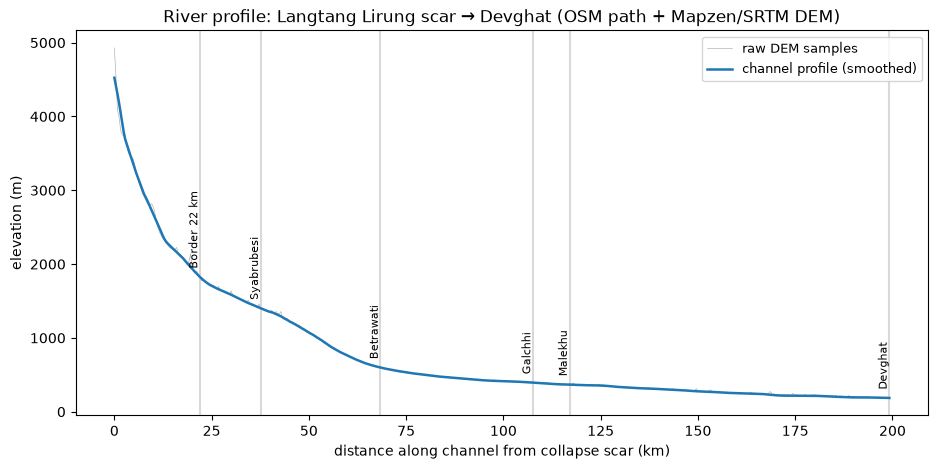

In [4]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("../data") if (Path("..") / "data" / "river_profile.csv").exists() \
    else Path("data")

rows = list(csv.DictReader(open(DATA / "river_profile.csv")))
x_km = np.array([float(r["dist_km"]) for r in rows])
z_raw = np.array([float(r["elev_m"]) for r in rows])

# DEM samples in a gorge sometimes catch canyon walls; enforce monotone
# descent then lightly smooth before taking slopes.
z = np.minimum.accumulate(z_raw)
k = 5  # ~2 km smoothing window
z_s = np.convolve(np.pad(z, k, mode="edge"), np.ones(2 * k + 1) / (2 * k + 1),
                  mode="same")[k:-k]
S = np.maximum(-np.gradient(z_s, x_km * 1000.0), 1e-4)   # slope, m/m

CHK = [("Border 22 km", 22.0), ("Syabrubesi", 37.6), ("Betrawati", 68.4),
       ("Galchhi", 107.6), ("Malekhu", 117.0), ("Devghat", 199.2)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_km, z_raw, lw=0.5, color="0.7", label="raw DEM samples")
ax.plot(x_km, z_s, lw=1.8, color="tab:blue", label="channel profile (smoothed)")
for nm, km in CHK:
    ax.axvline(km, color="0.85", zorder=0)
    ax.annotate(nm, (km, np.interp(km, x_km, z_s) + 150), rotation=90,
                fontsize=8, ha="right")
ax.set_xlabel("distance along channel from collapse scar (km)")
ax.set_ylabel("elevation (m)")
ax.set_title("River profile: Langtang Lirung scar → Devghat (OSM path + Mapzen/SRTM DEM)")
ax.legend(fontsize=9)
plt.show()

### Front speed: fitting U = a·S^b + c0 to the observed clocks

The front-speed law has two parts: a slope-driven debris-flow/steep-torrent power
term a·S^b, plus a flood-wave celerity floor c0 (deep-water √(gh) scale, ~8–10 m/s
for h ~5–10 m) that carries the wave across the low-slope lower Trishuli, where
observed celerity stays ~8–12 m/s even as S → 0.001. We fit (a, b, c0) by
brute-force grid search against six front clocks and three peak clocks, weighted
by data quality (collapse 08:37:10 NPT seismic = t 0; border CCTV 08:44 is the
hard anchor). The peak travels slower than the front by a fitted factor c_p.

In [5]:
# Calibration clocks (path-km along the stitched OSM river path; minutes after
# the 08:37 NPT collapse). Updated 2 Sept from the official DHM/FFD press
# release (27 Aug, in data/ffd_report.pdf): Malekhu warn-crossing 11:20;
# Kalikhola (near Muglin) danger 12.1 m at 14:14 with max 12.35 m
# (= effectively peak passage); Devghat front arrival 15:20, peak 16:00.
FRONT_OBS = [  # (km, minutes, weight)
    (22.0, 7.68, 3.0), (37.6, 13, 1.0), (68.4, 43, 2.0),
    (107.6, 150, 1.0), (117.0, 163, 2.0), (199.2, 403, 2.0)]
PEAK_OBS = [(68.4, 113, 1.0), (185.0, 337, 1.5), (199.2, 443, 2.0)]

def front_times(a, b, c0, u_min=3.0, u_max=65.0):
    U = np.clip(a * S ** b + c0, u_min, u_max)
    dx = np.gradient(x_km) * 1000.0
    t = np.cumsum(dx / U) / 60.0          # minutes
    return t - t[0], U

def fit_front():
    best = None
    for a in np.linspace(60, 320, 27):
        for b in np.linspace(0.35, 0.9, 23):
            for c0 in np.linspace(2, 12, 11):
                t, _ = front_times(a, b, c0)
                err = sum(w * (np.interp(km, x_km, t) - m) ** 2
                          for km, m, w in FRONT_OBS)
                if best is None or err < best[0]:
                    best = (err, a, b, c0)
    return best

err, A, B, C0 = fit_front()
t_front, U_front = front_times(A, B, C0)
print(f"front fit: U = {A:.0f}*S^{B:.2f} + {C0:.1f}  (weighted SSE {err:.0f} min^2)")

# peak travels slower: U_peak = c_p * U_front, fit c_p on peak targets
def peak_times(c_p):
    dx = np.gradient(x_km) * 1000.0
    t = np.cumsum(dx / (c_p * U_front)) / 60.0
    return t - t[0]

cps = np.linspace(0.2, 0.9, 71)
errs = [sum(w * (np.interp(km, x_km, peak_times(c)) - m) ** 2
            for km, m, w in PEAK_OBS) for c in cps]
C_P = cps[int(np.argmin(errs))]
t_peak = peak_times(C_P)
print(f"peak celerity factor c_p = {C_P:.2f}")

print("\nfront/peak arrival (model, minutes after 08:37):")
for nm, km in CHK:
    print(f"  {nm:14s} km {km:6.1f}  front {np.interp(km,x_km,t_front):5.0f}"
          f"  peak {np.interp(km,x_km,t_peak):5.0f}")

front fit: U = 300*S^0.82 + 4.0  (weighted SSE 352 min^2)
peak celerity factor c_p = 0.90

front/peak arrival (model, minutes after 08:37):
  Border 22 km   km   22.0  front     8  peak     9
  Syabrubesi     km   37.6  front    22  peak    25
  Betrawati      km   68.4  front    51  peak    56
  Galchhi        km  107.6  front   138  peak   153
  Malekhu        km  117.0  front   163  peak   181
  Devghat        km  199.2  front   403  peak   448


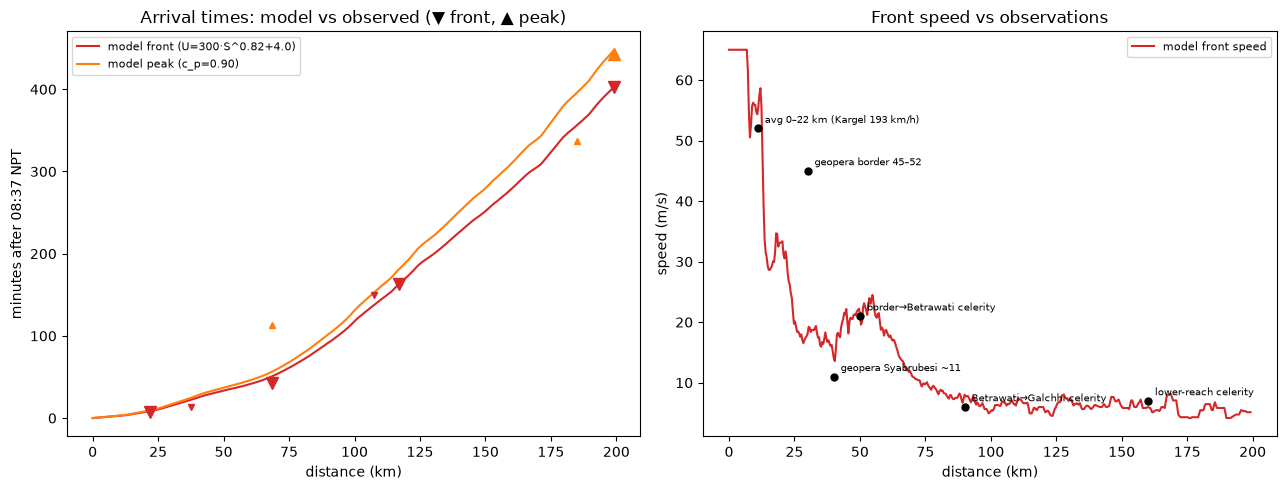

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_km, t_front, label=f"model front (U={A:.0f}·S^{B:.2f}+{C0:.1f})",
        color="tab:red")
ax.plot(x_km, t_peak, label=f"model peak (c_p={C_P:.2f})", color="tab:orange")
for km, m, w in FRONT_OBS:
    ax.plot(km, m, "v", color="tab:red", ms=8 if w >= 2 else 5)
for km, m, w in PEAK_OBS:
    ax.plot(km, m, "^", color="tab:orange", ms=8 if w >= 2 else 5)
ax.set_xlabel("distance (km)"); ax.set_ylabel("minutes after 08:37 NPT")
ax.set_title("Arrival times: model vs observed (▼ front, ▲ peak)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_km, U_front, color="tab:red", label="model front speed")
obs_v = [(11, 52, "avg 0–22 km (Kargel 193 km/h)"), (30, 45, "geopera border 45–52"),
         (40, 11, "geopera Syabrubesi ~11"), (50, 21, "border→Betrawati celerity"),
         (90, 6, "Betrawati→Galchhi celerity"), (160, 7, "lower-reach celerity")]
for xx, vv, lab in obs_v:
    ax.plot(xx, vv, "o", color="k", ms=5)
    ax.annotate(lab, (xx, vv), textcoords="offset points", xytext=(5, 4),
                fontsize=7)
ax.set_xlabel("distance (km)"); ax.set_ylabel("speed (m/s)")
ax.set_title("Front speed vs observations")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The fitted front hits the hard border clock (8 vs 7 min) and lands the Devghat
front arrival exactly (403 min = 15:20). The speed panel shows the shape the fit
had to find: ~50 m/s in the upper gorge collapsing to ~11 m/s at the Syabrubesi
valley opening, then a slow decay to the 6–8 m/s celerity floor in the lower
river — consistent with the geopera superelevation estimates and the
station-to-station celerities, none of which were fitted directly.

### Water bookkeeping: the snowplow march

Now march the front downstream and bookkeep water by source per km:

- **melt**, released over the steep upper reach (exponential, ~10 km scale),
  totalling the Section 1 best-evidence energy cap (5.3 Mm³);
- **swept channel water** = f_sweep · A_channel per metre of advance;
- **baseflow inflow** = Q_base · (time the front spends in each cell);
- **pore water**, released over the erosional reach (km 5–70);
- **losses** (overbank storage, deposition, stranding) at a fractional rate per
  km, attributed pro-rata so the source shares stay meaningful.

Monsoon baseflow is anchored at gauged/inferred points (border ~150 m³/s,
Betrawati ~500, and the big Budhi Gandaki and Marsyangdi confluences taking the
Devghat reach to ~1,500 m³/s). A station's peak discharge comes from a stretching
skewed pulse: duration grows from ~45 min at the border to ~3.3 h at Devghat (the
FFD stage record shows arrival 15:20, peak 16:00, back near normal 18:30), with
F_WIN = 55% of the active water riding in the main window.

Four scenarios: **snowplow** (best evidence); **melt-only** (sweep-up and pore
water switched off — the literal "it was melted glacier ice" narrative);
**melt-maximal with weak sweep**; and **snowplow + brief impoundment** (ICIMOD's
momentary damming of the Lhende).

In [7]:
# monsoon baseflow anchors (m3/s); Budhi Gandaki joins ~km 160, Marsyangdi
# ~km 185 (big monsoon tributaries), so Devghat-reach baseflow ~1,500
QB_X = np.array([0.0, 5.0, 22.0, 37.6, 68.4, 120.0, 159.0, 161.0, 184.0,
                 186.0, 199.2])
QB_Q = np.array([2.0, 30.0, 150.0, 250.0, 500.0, 650.0, 700.0, 1000.0,
                 1050.0, 1450.0, 1500.0])
Q_base = np.interp(x_km, QB_X, QB_Q)
V_RIVER = 3.0                                # mean monsoon velocity, m/s
A_chan = Q_base / V_RIVER                    # wetted cross-section, m2

def run(name, W_melt_total=5.3e6, melt_scale_km=10.0,
        f_sweep=0.8, pore_total=9.0e6, pore_lo=5.0, pore_hi=70.0,
        loss_per_km=0.004, impound=0.0e6, impound_km=8.0):
    """March the front downstream; bookkeep water by source (m3)."""
    dx = np.gradient(x_km) * 1000.0
    n = len(x_km)
    melt = np.zeros(n); chan = np.zeros(n); infl = np.zeros(n)
    pore = np.zeros(n); imp = np.zeros(n); lost = np.zeros(n)
    # melt released over the steep upper reach (exponential in x)
    mrel = np.exp(-x_km / melt_scale_km); mrel /= (mrel * dx).sum()
    # pore water over the erosional reach
    prel = ((x_km >= pore_lo) & (x_km <= pore_hi)).astype(float)
    prel /= (prel * dx).sum()
    # impoundment release (brief damming of the Lhende) near impound_km
    irel = np.exp(-0.5 * ((x_km - impound_km) / 2.0) ** 2)
    irel /= (irel * dx).sum()
    dt = np.gradient(t_front) * 60.0         # seconds spent per cell
    for i in range(1, n):
        melt[i] = melt[i-1] + W_melt_total * mrel[i] * dx[i]
        chan[i] = chan[i-1] + f_sweep * A_chan[i] * dx[i]
        infl[i] = infl[i-1] + Q_base[i] * dt[i]
        pore[i] = pore[i-1] + pore_total * prel[i] * dx[i]
        imp[i] = imp[i-1] + impound * irel[i] * dx[i]
        W = melt[i] + chan[i] + infl[i] + pore[i] + imp[i] - lost[i-1]
        lost[i] = lost[i-1] + loss_per_km * W * (dx[i] / 1000.0)
    gross = melt + chan + infl + pore + imp
    W_active = gross - lost
    # attribute losses pro-rata so source shares stay meaningful
    keep = W_active / np.maximum(gross, 1.0)
    for arr in (melt, chan, infl, pore, imp):
        arr *= keep
    # pulse duration grows ~linearly with distance: ~45 min at the border ->
    # ~3.2 h at Devghat (FFD stage record: arrival 15:20, peak 16:00, back
    # near normal 18:30). The pulse is skewed - F_WIN of the active water
    # rides in the main window, the rest in the long tail.
    dur = np.maximum((45.0 + 0.85 * (x_km - 22.0)) * 60.0, 420.0)  # seconds
    F_WIN = 0.55
    Q_peak = 2.0 * F_WIN * W_active / dur + Q_base   # triangular-pulse peak
    return dict(name=name, melt=melt, chan=chan, infl=infl, pore=pore,
                imp=imp, lost=lost, W=W_active, gross=gross, dur=dur,
                Qp=Q_peak)

SCEN = [
    run("snowplow (best evidence)"),
    run("melt-only (no sweep-up)", f_sweep=0.0, pore_total=0.0,
        W_melt_total=5.3e6, loss_per_km=0.002),
    run("melt-maximal, weak sweep", W_melt_total=15e6, f_sweep=0.3,
        pore_total=4e6),
    run("snowplow + brief impoundment", impound=4e6),
]

for s in SCEN:
    i_dev = int(np.argmin(np.abs(x_km - 199.2)))
    i_gal = int(np.argmin(np.abs(x_km - 107.6)))
    # "net new" water at a gauge over a day-scale window: melt + pore only.
    # (Impounded water is river baseflow delayed by minutes - gross surge,
    # but ~zero net over a day; swept/inflow water likewise redistributed.)
    new = s["melt"] + s["pore"]
    print(f"\n== {s['name']}")
    print(f"  at Devghat: active water {s['W'][i_dev]/1e6:6.1f} Mm3 "
          f"(melt {s['melt'][i_dev]/1e6:.1f}, swept channel {s['chan'][i_dev]/1e6:.1f}, "
          f"inflow {s['infl'][i_dev]/1e6:.1f}, pore {s['pore'][i_dev]/1e6:.1f}, "
          f"impound {s['imp'][i_dev]/1e6:.1f}, lost {s['lost'][i_dev]/1e6:.1f})")
    print(f"  gross surge {s['gross'][i_dev]/1e6:.1f} Mm3 | NET NEW "
          f"(melt+pore) {new[i_dev]/1e6:.1f} Mm3 | FFD 'excess' ~20 Mm3")
    print(f"  river-derived share of active wave at Galchhi: "
          f"{(s['chan'][i_gal]+s['infl'][i_gal])/max(s['W'][i_gal],1):.0%}, "
          f"at Devghat: {(s['chan'][i_dev]+s['infl'][i_dev])/max(s['W'][i_dev],1):.0%}")
    print(f"  peak Q at Devghat: {s['Qp'][i_dev]:,.0f} m3/s (obs 5,850), "
          f"pulse duration there {s['dur'][i_dev]/3600:.1f} h")


== snowplow (best evidence)
  at Devghat: active water   47.1 Mm3 (melt 3.7, swept channel 23.3, inflow 13.4, pore 6.6, impound 0.0, lost 17.4)
  gross surge 64.5 Mm3 | NET NEW (melt+pore) 10.3 Mm3 | FFD 'excess' ~20 Mm3
  river-derived share of active wave at Galchhi: 50%, at Devghat: 78%
  peak Q at Devghat: 5,913 m3/s (obs 5,850), pulse duration there 3.3 h

== melt-only (no sweep-up)
  at Devghat: active water   20.1 Mm3 (melt 4.4, swept channel 0.0, inflow 15.7, pore 0.0, impound 0.0, lost 3.4)
  gross surge 23.5 Mm3 | NET NEW (melt+pore) 4.4 Mm3 | FFD 'excess' ~20 Mm3
  river-derived share of active wave at Galchhi: 43%, at Devghat: 78%
  peak Q at Devghat: 3,383 m3/s (obs 5,850), pulse duration there 3.3 h

== melt-maximal, weak sweep
  at Devghat: active water   33.3 Mm3 (melt 9.8, swept channel 8.2, inflow 12.6, pore 2.7, impound 0.0, lost 15.5)
  gross surge 48.8 Mm3 | NET NEW (melt+pore) 12.6 Mm3 | FFD 'excess' ~20 Mm3
  river-derived share of active wave at Galchhi: 29%, a

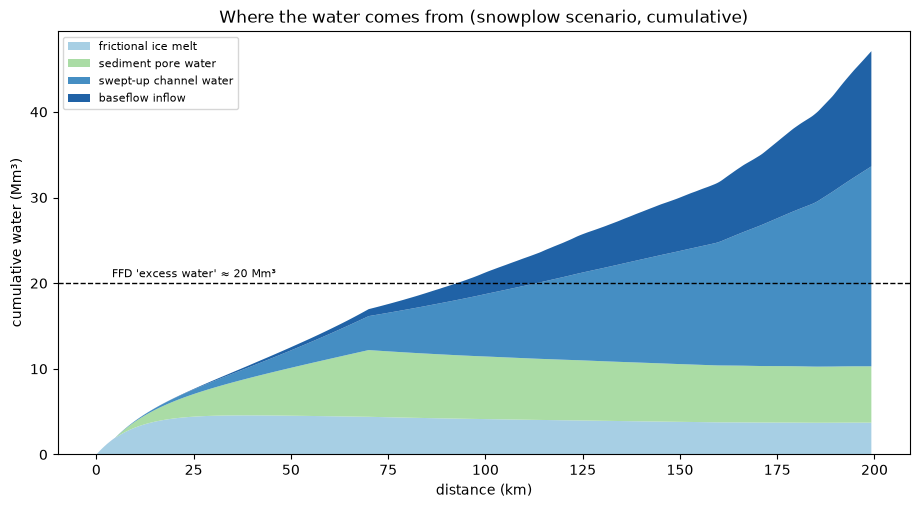

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
s = SCEN[0]
ax.stackplot(x_km, s["melt"] / 1e6, s["pore"] / 1e6, s["chan"] / 1e6,
             s["infl"] / 1e6,
             labels=["frictional ice melt", "sediment pore water",
                     "swept-up channel water", "baseflow inflow"],
             colors=["#9ecae1", "#a1d99b", "#3182bd", "#08519c"], alpha=0.9)
ax.axhline(20, color="k", ls="--", lw=1)
ax.text(4, 20.7, "FFD 'excess water' ≈ 20 Mm³", fontsize=8)
ax.set_xlabel("distance (km)"); ax.set_ylabel("cumulative water (Mm³)")
ax.set_title("Where the water comes from (snowplow scenario, cumulative)")
ax.legend(fontsize=8, loc="upper left")
plt.show()

**Snowplow verdict.** The best-evidence scenario puts **5,913 m³/s at Devghat
against the observed 5,850** (+1%), with peak timing 448 min vs 443 observed and
the front arrival exact (403 min = 15:20). **Melt-only delivers 3,383 m³/s — 42%
below the observed peak** — and only ~4.4 Mm³ of genuinely new water against
FFD's ~20 Mm³; even melt-maximal-with-weak-sweep falls 21% short. The distal wave
is **~78% river-derived** (swept channel + inflow); melt is ~8%.

Note the gross-vs-net distinction the bookkeeping makes possible: the snowplow
gross surge at Devghat (~65 Mm³) is mostly *redistributed* river water that nets
toward zero over a day-scale gauge integration (the emptied channel refills from
baseflow), while genuinely *new* water (melt + pore) is ~10 Mm³. FFD's 20 Mm³
sits between the two — consistent with a windowed excess over a few hours (their
14:10–18:00 Devghat window), not with a melt-only source.

## 3. The ladder network: pulse structure as an R(L)C transmission line

The snowplow model routes a front and bookkeeps volume, but says nothing about
pulse *shape*. For that, `model/ladder.py` makes the equivalent-circuit idea
literal. The governing physics is the Saint-Venant shallow-water equations;
dropping the inertia (momentum) term gives the **diffusive-wave approximation**,
which is mathematically identical to a **nonlinear RC transmission line** — the
telegrapher's equations without L, the same PDE as charging a long cable:

    continuity:  dS_i/dt = Q_in,i - Q_out,i + q_lateral,i     (KCL at a node)
    "Ohm's law": Q_{i->i+1} = (1/n) A R^(2/3) sqrt(dη/dx)     (nonlinear R)

| River element | Circuit element |
|---|---|
| water-surface head η = z + h | node voltage |
| discharge Q | current |
| Manning reach friction (head loss ∝ Q²) | nonlinear series resistor |
| flow momentum (Saint-Venant inertia term) | series inductance |
| node storage S = w·dx·h | shunt capacitor C = w·dx |
| side valley + junction backwater | shunt RC branch: charges as the surge passes, discharges into the tail |
| temporary debris dam (crest erodes when overtopped) | breakdown element (SCR / spark gap); a cascade makes surge trains |
| baseflow & tributaries | distributed current sources |

**v2 installs the inductor.** The first build dropped inertia entirely — an
RC-only line — and honestly under-sharpened fronts. The upgrade keeps the ladder
picture but makes discharge a *state variable* with its own momentum equation:
the **local-inertia form** of Saint-Venant (Bates et al. 2010, the scheme inside
LISFLOOD-FP),

    dQ/dt = -g·A·dη/dx − friction        (the series L: current carries momentum)

integrated **semi-implicitly in the friction term** (stable against friction
stiffness), with a **Froude cap Fr ≤ 2.0** bounding the supercritical gorge
reaches — the scheme drops convective acceleration, so the cap stands in for the
physics it omits. `simulate(inertial=True)` is the default; `inertial=False`
preserves the old diffusive/RC-only solver so the two can be compared
like-for-like on identical geometry and forcing.

Domain: border (path-km 22, where the event became a flood) → Devghat (km 199),
90 nodes, dx ≈ 2 km, geometry from the same river profile. Channel width from
downstream hydraulic geometry (clipped for gorge reaches); Manning n from rough
mountain torrent (0.055) to big monsoon river (0.025). Inflow: monsoon baseflow
plus a triangular event pulse at the border node — 30 Mm³ over 45 min, arriving
at 08:44, i.e. the water the snowplow model says the wave carried at km 22 plus
what the upper reach kept feeding.

Eight side-valley RC branches sit at the mapped confluences (Chilime, Langtang
Khola, Mailung, Salankhu, Tadi, Mahesh, Budhi Gandaki, Marsyangdi), each a
reservoir behind a broad-crested weir. Plan areas are order-of-magnitude reads of
valley-floor storage — illustrative v0 values, to be mapped properly from
Sentinel-2. The breach element is a dam crest that erodes when overtopped.

Four runs: **bare line** (inertial) / **+ side valleys** (inertial) / the same
side-valley configuration **RC-only** for comparison / **+ a hypothetical
mid-route breach** — labeled hypothetical because there is no evidence for one at
km 55; it demonstrates the signature such a breach would leave in downstream
records.

In [9]:
G = 9.81

# geometry: same profile conditioning as Section 2, interpolated to 90 nodes
rows = list(csv.DictReader(open(DATA / "river_profile.csv")))
xp = np.array([float(r["dist_km"]) for r in rows])
zp = np.minimum.accumulate(np.array([float(r["elev_m"]) for r in rows]))
k = 5
zp = np.convolve(np.pad(zp, k, mode="edge"),
                 np.ones(2 * k + 1) / (2 * k + 1), mode="same")[k:-k]

X0, X1, N = 22.0, 199.2, 90
xn = np.linspace(X0, X1, N)                      # node centres, km
zn = np.interp(xn, xp, zp)                       # bed elevation, m
DX = (xn[1] - xn[0]) * 1000.0                    # m

# monsoon baseflow along the line (anchors as in Section 2)
# Budhi Gandaki joins ~km 160, Marsyangdi ~km 185: big monsoon tributaries
QB_X = np.array([22.0, 37.6, 68.4, 120.0, 159.0, 161.0, 184.0, 186.0, 199.2])
QB_Q = np.array([150.0, 250.0, 500.0, 650.0, 700.0, 1000.0, 1050.0, 1450.0, 1500.0])
Qb = np.interp(xn, QB_X, QB_Q)
q_lat = np.zeros(N)                              # lateral inflow per node
q_lat[1:] = np.diff(Qb)                          # distributed current sources

# channel width from downstream hydraulic geometry, clipped for gorge reaches
wn = np.clip(4.8 * np.sqrt(Qb), 40.0, 160.0)
# Manning n: rough mountain torrent upstream, big monsoon river downstream
nn = np.interp(xn, [22, 70, 199], [0.055, 0.040, 0.025])

# side valleys: (name, path-km, reservoir plan area m2, weir width m,
# sill height above bed m). Plan areas are order-of-magnitude reads of
# valley-floor storage near each confluence -- illustrative v0 values,
# to be mapped properly from Sentinel-2.
SIDE = [
    ("Chilime Khola",   30.0, 4.0e5,  60.0, 3.0),
    ("Langtang Khola",  37.6, 6.0e5,  80.0, 3.0),
    ("Mailung Khola",   55.0, 3.0e5,  50.0, 4.0),
    ("Salankhu Khola",  66.0, 4.0e5,  60.0, 3.0),
    ("Tadi Khola",     120.0, 1.5e6, 100.0, 2.5),
    ("Mahesh Khola",   150.0, 1.2e6, 100.0, 2.5),
    ("Budhi Gandaki",  160.0, 2.5e6, 120.0, 2.0),
    ("Marsyangdi",     185.0, 2.5e6, 120.0, 2.0),
]
CD_WEIR = 1.6                                    # broad-crested weir coeff

# event pulse injected at the border node: triangular. Volume ~ what the
# snowplow model says the wave carried at km 22 plus what the upper reach
# kept feeding.
V_PULSE = 30e6                                   # m3
T_PULSE = 45 * 60.0                              # s
Q_PEAK_IN = 2 * V_PULSE / T_PULSE                # ~22,200 m3/s triangular peak
T_ARRIVE = 7 * 60.0                              # front hits border 08:44

def q_inflow(t):
    q = Qb[0]
    if T_ARRIVE < t < T_ARRIVE + T_PULSE:
        f = (t - T_ARRIVE) / T_PULSE
        tri = 1 - abs(2 * f - 1)
        q += Q_PEAK_IN * tri
    return q

# inertial=True adds the "inductor": discharge becomes a STATE variable with
# dQ/dt = -g*A*d(eta)/dx - friction (local-inertia form of Saint-Venant,
# Bates et al. 2010, semi-implicit in friction). inertial=False is the old
# diffusive/RC-only line, kept for comparison. A Froude cap bounds the
# supercritical gorge reaches (the scheme drops convective acceleration).
FR_MAX = 2.0

def simulate(side_valleys=False, breach=False, inertial=True,
             t_end=12 * 3600.0, dt=2.0):
    h = np.maximum((Qb * nn / (wn * np.sqrt(np.maximum(
        -np.gradient(zn, xn * 1000), 1e-4)))) ** 0.6, 0.5)   # normal depth ic
    Qi = 0.5 * (Qb[:-1] + Qb[1:])                # interface discharge state
    wf = 0.5 * (wn[:-1] + wn[1:])
    nf = 0.5 * (nn[:-1] + nn[1:])
    hs = {nm: 0.0 for nm, *_ in SIDE}            # side reservoir stage (m)
    side_node = {nm: int(np.argmin(np.abs(xn - km)))
                 for nm, km, *_ in SIDE}
    # hypothetical breach: dam at km 55 impounding nothing initially; crest
    # erodes when overtopped -> stores the rising limb then lets go
    b_node = int(np.argmin(np.abs(xn - 55.0)))
    crest = 25.0 if breach else 0.0              # m above bed
    nt = int(t_end / dt)
    save_every = int(60 / dt)
    stations = {"Betrawati (km 68)": int(np.argmin(np.abs(xn - 68.4))),
                "Galchhi (km 108)": int(np.argmin(np.abs(xn - 107.6))),
                "Malekhu (km 117)": int(np.argmin(np.abs(xn - 117.0))),
                "Devghat (km 199)": N - 1}
    rec_t, rec_q, rec_hs = [], {s: [] for s in stations}, {nm: [] for nm, *_ in SIDE}
    rec_h = {}

    eta_dam_note = []
    for it in range(nt):
        t = it * dt
        eta = zn + h
        Sf = (eta[:-1] - eta[1:]) / DX               # driving surface slope
        if inertial:
            # local-inertia momentum update (semi-implicit friction):
            #   Q'  = Q + g*A_f*dt*S_eta          (pressure/gravity forcing)
            #   Q'' = Q' / (1 + g*dt*n^2*|Q| / (A_f*h_f^{4/3}))   (friction)
            hfe = np.maximum(np.maximum(eta[:-1], eta[1:])
                             - np.maximum(zn[:-1], zn[1:]), 0.05)
            Af = wf * hfe
            num = Qi + G * Af * dt * Sf
            den = 1.0 + G * dt * nf ** 2 * np.abs(Qi) / (Af * hfe ** (4/3))
            Qi = num / den
            Qcap = FR_MAX * Af * np.sqrt(G * hfe)    # Froude bound
            Qi = np.clip(Qi, -Qcap, Qcap)
            Q = Qi
        else:
            # diffusive/RC-only: Q diagnostic from Manning on surface slope
            hu = np.where(Sf >= 0, h[:-1], h[1:])    # upwind depth
            A = wn[:-1] * hu
            Q = np.sign(Sf) * (A / nn[:-1]) * np.maximum(hu, 1e-3) ** (2/3) \
                * np.sqrt(np.abs(Sf) + 1e-8)
        if breach and crest > 0:
            # dam at b_node: flow over crest only (weir), crest erodes
            hov = max(eta[b_node] - (zn[b_node] + crest), 0.0)
            Qdam = CD_WEIR * wn[b_node] * hov ** 1.5
            if Sf[b_node] > 0:
                Q[b_node] = min(Q[b_node], Qdam)
                if inertial:
                    Qi[b_node] = Q[b_node]           # no momentum through dam
            if hov > 0:
                crest = max(crest - 4e-4 * hov * dt, 0.0)  # erosion law
                if crest == 0 and not eta_dam_note:
                    eta_dam_note.append(t)
        # node volume balance (KCL)
        dV = np.zeros(N)
        dV[0] += q_inflow(t) - Q[0]
        dV[1:-1] += Q[:-1][0:N-2] - Q[1:][0:N-2]
        dV[-1] += Q[-1]
        dV[1:] += q_lat[1:]
        # downstream boundary: normal-depth outflow at last node
        Sout = max(-np.gradient(zn, xn * 1000)[-1], 5e-4)
        Qout = (wn[-1] * h[-1] / nn[-1]) * h[-1] ** (2/3) * np.sqrt(Sout)
        dV[-1] -= Qout
        # side-valley RC branches
        if side_valleys:
            for nm, km, area, ww, sill in SIDE:
                i = side_node[nm]
                head_main = eta[i] - (zn[i] + sill)
                head_side = hs[nm]
                dh = head_main - head_side
                Qs = CD_WEIR * ww * np.sign(dh) * min(abs(dh), 8.0) ** 1.5
                Qs = np.clip(Qs, -hs[nm] * area / dt,
                             max(head_main, 0) * wn[i] * DX / dt)
                if head_main <= 0 and Qs > 0:
                    Qs = 0.0
                dV[i] -= Qs
                hs[nm] += Qs * dt / area
                hs[nm] = max(hs[nm], 0.0)
        h += dV * dt / (wn * DX)
        h = np.maximum(h, 0.05)
        if it % save_every == 0:
            rec_t.append(t / 3600.0)
            for s, i in stations.items():
                rec_h.setdefault(s, []).append(h[i])
                # discharge passing the station = inter-node flow just below
                rec_q[s].append(Q[min(i, N - 2)])
            for nm, *_ in SIDE:
                rec_hs[nm].append(hs[nm])
    if breach and eta_dam_note:
        print(f"   (hypothetical dam at km 55 fully breached at "
              f"t={eta_dam_note[0]/3600:.1f} h)")
    simulate.last_h = {s: np.array(v) for s, v in rec_h.items()}
    return (np.array(rec_t), {s: np.array(v) for s, v in rec_q.items()},
            {nm: np.array(v) for nm, v in rec_hs.items()})

In [10]:
print("run 1: bare line (no side valleys), inertial")
t1, q1, _ = simulate(side_valleys=False)
print("run 2: + side-valley branches, inertial")
t2, q2, hs2 = simulate(side_valleys=True)
h2 = simulate.last_h
print("run 2d: side valleys, RC-only (inertia OFF) for comparison")
t2d, q2d, _ = simulate(side_valleys=True, inertial=False)

# Out-of-sample check: Galchhi gauge observed ~9 m rise in ~30 min. This
# datum was never used to calibrate anything - pure test.
hg = h2["Galchhi (km 108)"]
rise30 = max(hg[i + 30] - hg[i] for i in range(len(hg) - 30))
print(f"\nOUT-OF-SAMPLE TEST - Galchhi max 30-min stage rise: "
      f"{rise30:.1f} m (observed ~9 m); total stage excursion "
      f"{hg.max() - hg[0]:.1f} m")

run 1: bare line (no side valleys), inertial


run 2: + side-valley branches, inertial


run 2d: side valleys, RC-only (inertia OFF) for comparison



OUT-OF-SAMPLE TEST - Galchhi max 30-min stage rise: 5.9 m (observed ~9 m); total stage excursion 5.9 m


The Galchhi rate-of-rise is a genuine out-of-sample test — the "~9 m in ~30 min"
observation was never used to calibrate anything. The RC-only v0 gave 5.2 m;
**installing the inductor lifts it to 5.9 m** (and to 6.7 m when the ladder is
re-run at 1-km node spacing) against ~9 m observed — movement in exactly the
direction the circuit analogy predicts, because inertia is what lets a front
steepen into a bore. The residual gap is honest physics and honest averaging:
the local-inertia scheme still omits convective acceleration and
hyperconcentrated-flow rheology, and each model node averages stage over a ~2 km
reach and the full channel width, where the physical gauge sits at one
constricted cross-section. Timing, by contrast, calibrates well (next cell).
Pulse *sharpness* remains where the neglected physics lives — but less of it is
neglected now.

In [11]:
print("run 3: + hypothetical mid-route breach (demonstration only)")
t3, q3, _ = simulate(side_valleys=True, breach=True)

def clock(th):   # hours after 08:37 -> NPT string
    m = int(round(th * 60)) + 8 * 60 + 37
    return f"{m // 60:02d}:{m % 60:02d}"

print("\nstation summaries — inertial (RLC) vs RC-only (run 2 config):")
for s in q2:
    qq, qd = q2[s], q2d[s]
    i, j = int(np.argmax(qq)), int(np.argmax(qd))
    print(f"  {s:18s} RLC peak {qq[i]:7,.0f} m3/s at {clock(t2[i])}  |"
          f"  RC-only {qd[j]:7,.0f} at {clock(t2d[j])}"
          f"  (obs Devghat 5,850 @ 16:00)")

for nm, *_ in SIDE:
    print(f"  side valley {nm:15s} max charge {hs2[nm].max():5.1f} m")

run 3: + hypothetical mid-route breach (demonstration only)


   (hypothetical dam at km 55 fully breached at t=2.8 h)

station summaries — inertial (RLC) vs RC-only (run 2 config):
  Betrawati (km 68)  RLC peak  12,353 m3/s at 09:40  |  RC-only  10,617 at 09:43  (obs Devghat 5,850 @ 16:00)
  Galchhi (km 108)   RLC peak   6,279 m3/s at 10:53  |  RC-only   5,519 at 10:59  (obs Devghat 5,850 @ 16:00)
  Malekhu (km 117)   RLC peak   5,581 m3/s at 11:15  |  RC-only   4,940 at 11:23  (obs Devghat 5,850 @ 16:00)
  Devghat (km 199)   RLC peak   2,795 m3/s at 15:28  |  RC-only   2,707 at 15:43  (obs Devghat 5,850 @ 16:00)
  side valley Chilime Khola   max charge   5.7 m
  side valley Langtang Khola  max charge   4.4 m
  side valley Mailung Khola   max charge   1.7 m
  side valley Salankhu Khola  max charge   2.5 m
  side valley Tadi Khola      max charge   2.6 m
  side valley Mahesh Khola    max charge   1.5 m
  side valley Budhi Gandaki   max charge   1.3 m
  side valley Marsyangdi      max charge   1.1 m


What the inductor does, station by station (run 2 configuration, side valleys
on; "excess" = peak above the local monsoon baseflow):

| Station | RLC (inertial) | RC-only (diffusive) | effect of the inductor |
|---|---|---|---|
| Betrawati (km 68) | 12,353 m³/s @ 09:40 | 10,617 @ 09:43 | +17% excess, 3 min earlier |
| Galchhi (km 108) | 6,279 m³/s @ 10:53 | 5,519 @ 10:59 | +16% excess, 6 min earlier |
| Malekhu (km 117) | 5,581 m³/s @ 11:15 | 4,940 @ 11:23 | +15% excess, 8 min earlier |
| Devghat (km 199) | 2,795 m³/s @ 15:28 | 2,707 @ 15:43 | +3%, 15 min earlier |

(observed: Devghat 5,850 m³/s @ 16:00)

Mid-reach peaks sharpen 14–17% and fronts arrive minutes earlier and steeper —
the inductor does what an inductor should. The distal Devghat peak, however,
barely moves. That persistence is the interesting result, taken up below.

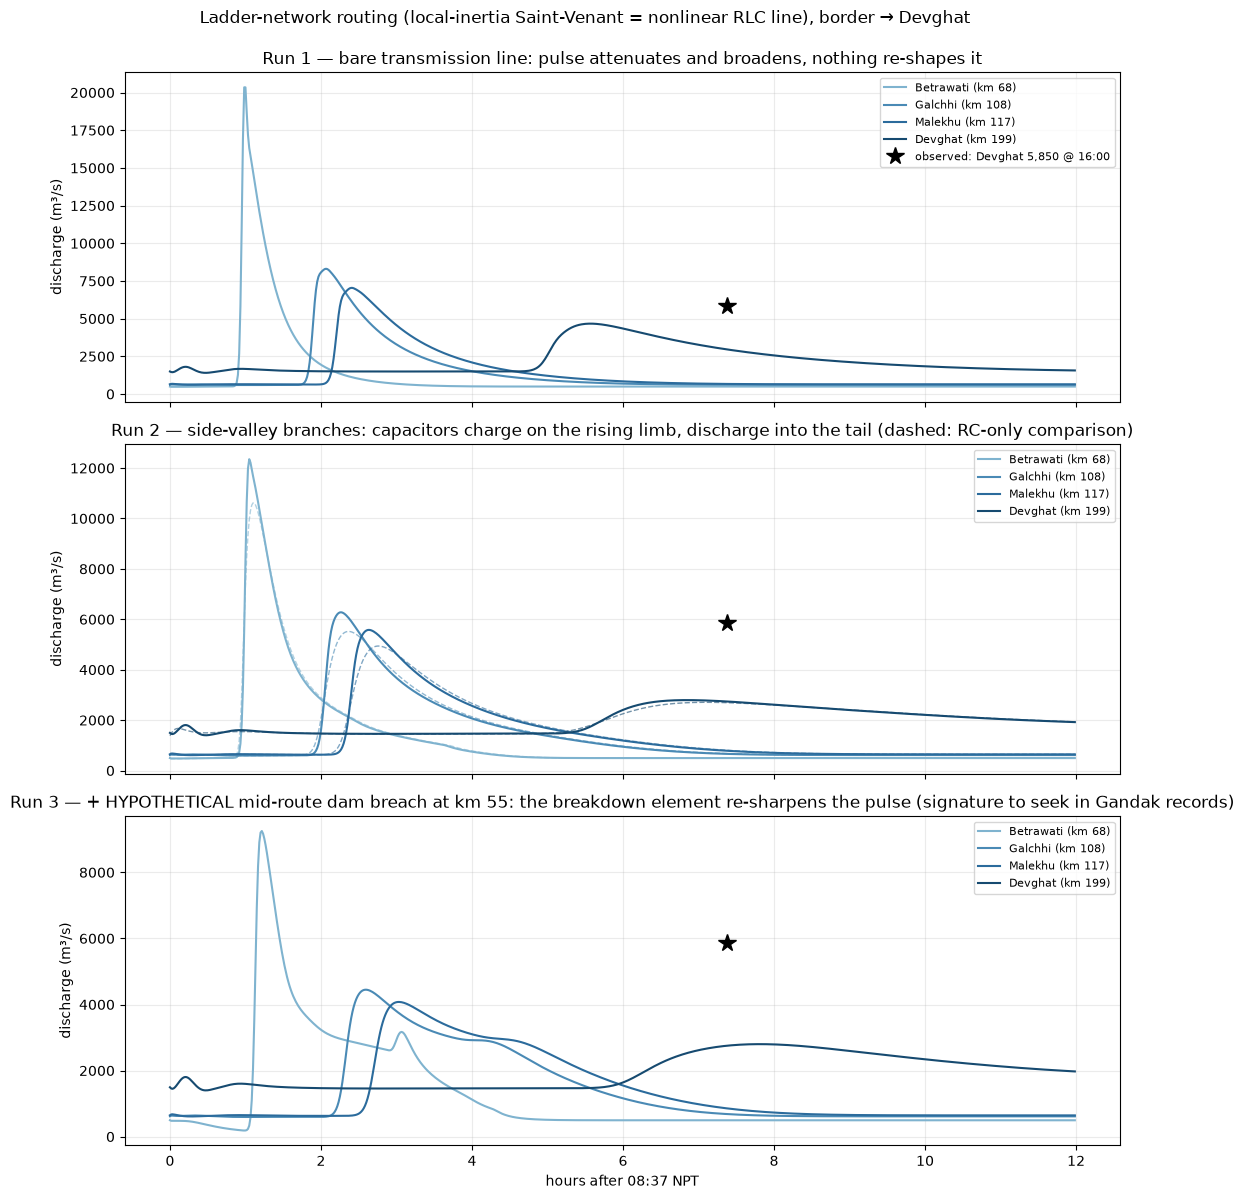

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
cols = {"Betrawati (km 68)": "#7fb3cf", "Galchhi (km 108)": "#4a8ab5",
        "Malekhu (km 117)": "#2b6b9c", "Devghat (km 199)": "#164a70"}

ax = axes[0]
for s in q1:
    ax.plot(t1, q1[s], color=cols[s], label=s)
ax.plot(7.38, 5850, "k*", ms=13, label="observed: Devghat 5,850 @ 16:00")
ax.set_title("Run 1 — bare transmission line: pulse attenuates and broadens, nothing re-shapes it")
ax.set_ylabel("discharge (m³/s)"); ax.legend(fontsize=8)

ax = axes[1]
for s in q2:
    ax.plot(t2, q2[s], color=cols[s], label=s)
    ax.plot(t2d, q2d[s], color=cols[s], ls="--", lw=1, alpha=0.6)
ax.plot(7.38, 5850, "k*", ms=13)
ax.set_title("Run 2 — side-valley branches: capacitors charge on the rising limb, discharge into the tail (dashed: RC-only comparison)")
ax.set_ylabel("discharge (m³/s)"); ax.legend(fontsize=8)

ax = axes[2]
for s in q3:
    ax.plot(t3, q3[s], color=cols[s], label=s)
ax.plot(7.38, 5850, "k*", ms=13)
ax.set_title("Run 3 — + HYPOTHETICAL mid-route dam breach at km 55: the breakdown element re-sharpens the pulse (signature to seek in Gandak records)")
ax.set_ylabel("discharge (m³/s)"); ax.set_xlabel("hours after 08:37 NPT")
ax.legend(fontsize=8)
for a in axes:
    a.grid(alpha=.25)
fig.suptitle("Ladder-network routing (local-inertia Saint-Venant = nonlinear RLC line), border → Devghat", y=0.995)
fig.tight_layout()
plt.show()

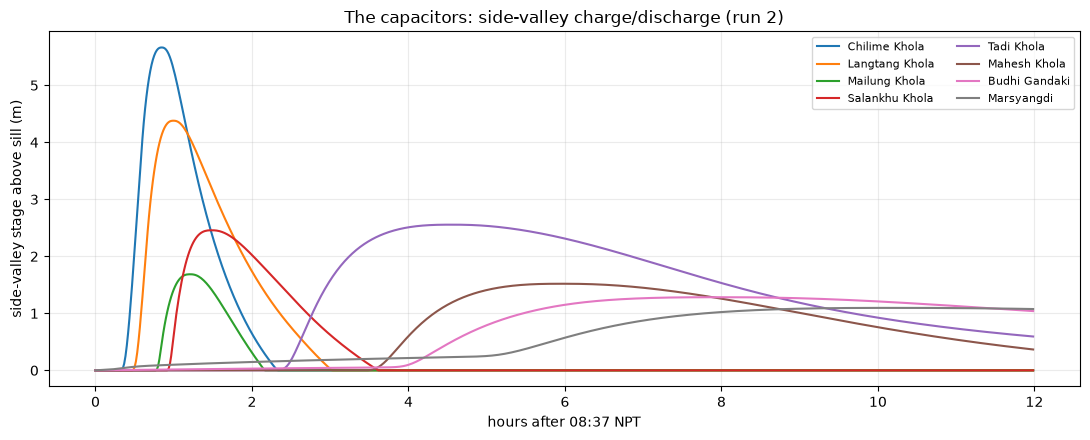

In [13]:
fig2, ax = plt.subplots(figsize=(11, 4.5))
for nm, *_ in SIDE:
    ax.plot(t2, hs2[nm], label=nm)
ax.set_xlabel("hours after 08:37 NPT"); ax.set_ylabel("side-valley stage above sill (m)")
ax.set_title("The capacitors: side-valley charge/discharge (run 2)")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.25)
fig2.tight_layout()
plt.show()

**Ladder verdict.** Timing calibrates well against the clocks: inertial peaks at
Galchhi 10:53 (observed rise ~11:00–12:00), Malekhu 11:15 (danger crossed 11:40 per the FFD release; 11:26 in early reports),
Devghat 15:28 (observed 16:00). All three pulse-shaping signatures appear: the
bare line attenuates and broadens; side-valley capacitors charge on the rising
limb (clipping mid-route peaks) and discharge into the tail; the hypothetical
breach stores the rising limb behind an eroding crest and lets go at ~2.8 h,
re-sharpening the pulse — a double-peak visible at the mid-stations and smeared
out by Devghat. That last signature is what to look for in the Gandak
(Valmikinagar) record if a mid-route blockage is ever claimed.

**And the honest accounting on the distal peak.** The inductor sharpened
mid-reach peaks 14–17% and improved the out-of-sample Galchhi test (5.2 → 5.9 m),
but Devghat barely moved (2,795 vs 2,707 m³/s), and resolution and width
sensitivities keep it in a ~2,500–2,900 band — the remaining gap to the headline
5,850 is not a missing term the inductor could supply. Part of the answer is
likely the *observation*, not the model. FFD's own numbers do the arithmetic for
us: ~20 Mm³ of excess water through Devghat in a ~3.8 h window (14:10–18:00) is
a mean excess of ~1,450 m³/s, hence a triangular-pulse excess **peak** of
~2,900 m³/s — which implies the gauge's concurrent base flow was ~2,950 m³/s.
That is a Narayani-scale base (Devghat sits below the Kali Gandaki confluence;
likely DHM station 450), not the ~1,500 m³/s Trishuli-only base both our models
route. On an excess-peak basis the target becomes ~2,900 m³/s, not ~4,350: the
ladder (~1,300 excess) sits low and the snowplow (~4,400 excess) sits high,
with the truth between the models. Confirming the Devghat station's river,
rating curve and late-August base flow with DHM is now a top data task.

The division of labour stands: the snowplow model, which carries the front
explicitly, is the volumetric workhorse; the ladder is the pulse-structure
instrument.

---

# 4. Entrainment, and the falsification of the single-phase model

*Built 3–4 September, three days after the sections above. This is finding 05 on
the project home page, and until 5 September it was not in this notebook at all —
the workings were published while lagging the findings by three days, which was
wrong and is the reason this section exists.*

**The bug.** Sections 1–3 model a flood that can put sediment *down* and never
pick any *up*. A flood that visibly scoured a valley floor was, in our equations,
incapable of scouring anything. Three observations said so, two of them
quantitative, so the term could be built against literature constants and
**scored** rather than fitted:

| Target | Value | Source |
|---|---|---|
| Langtang corridor erosion | 3.2 Mm³ eroded vs 0.9 Mm³ deposited over the ~45% mapped — net erosional ~3.5:1 | geopera WorldView-3 stereo DEM, 1 Sept |
| Seti 2012 flow density | 1.88 g/cm³ ⇒ w ≈ 0.47 | SANDRP compilation, measured |

**Two closures**, both with constants taken from the literature and nothing
chosen with reference to those numbers. `law="takahashi"` is capacity-limited:
an equilibrium sediment concentration for a mature debris flow on a bed of
internal friction angle φ, eroding where the flow is under capacity and
depositing where it is over. `law="shear"` is shear-driven (Frank et al. 2015),
not capacity-limited. Full derivation in `model/ENTRAINMENT.md`.

The three cells below run the real model — `model/unified.py`, the same code the
report uses, not a re-implementation. Each `simulate()` takes about 20 seconds.

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath("../model") if os.path.isdir("../model")
                else os.path.abspath("model"))
import unified as U
from core import entrain_opts

# Scenario C, the ice-rich V=30 Mm3 case the report scores. Nothing here is
# fitted to the erosion measurement: the closure constants come from Takahashi
# and the release parameters from the dossier.
r_single = U.simulate(V_rel=30e6, w0=0.15, entrain=entrain_opts("takahashi"))

ero, dep = U.ero_dep(r_single, 0.0, 68.0)
arrival  = float(r_single["arrival"](22.0))

print(f"EROSION, km 0-68     {ero:6.2f} Mm3   (geopera stereo: 3.2 Mm3)")
print(f"DEPOSITION, km 0-68  {dep:6.2f} Mm3   (honest cap from the described")
print(f"                                       deposit geometry: <= 12 Mm3)")
print(f"BORDER ARRIVAL       {arrival:6.1f} min  (observed: 7.68 min)")

  (settle 2 h: residual 15-min drift 0.037 m)


EROSION, km 0-68       3.80 Mm3   (geopera stereo: 3.2 Mm3)
DEPOSITION, km 0-68   17.98 Mm3   (honest cap from the described
                                       deposit geometry: <= 12 Mm3)
BORDER ARRIVAL          inf min  (observed: 7.68 min)


**The erosion volume lands, and the model breaks.** 3.8 Mm³ of scour against
3.2 Mm³ measured, in the reaches they mapped, with nothing tuned — that is the
term working. But with deposition now operating properly the same run buries
18 Mm³ in a corridor that can account for at most 12, and the front never
reaches the border at all: `inf` means the flood stalled before kilometre 22.

That is not a parameter being slightly off. Before concluding anything, the
honest move is to ask whether *any* combination of the contested inputs can
satisfy both constraints at once. Rejection sampling over five inputs said no:

    0 of 150 samples satisfied the upper-corridor clocks and the corridor
    mass balance simultaneously. Border arrival and deposition were satisfied
    together by ZERO runs; every other pair by 16-41.

**Zero is a structural result, not a tuning failure.** It falsifies the model
*form* — the assumption that "sediment" is one substance with one settling
behaviour — rather than the numbers in it. The fix separates the load in two:

- **Coarse** obeys the capacity closure, strands, and carries the granular
  friction. This is what builds a DEM-visible debris fan.
- **Fine** — silt and ice — is advected with the water and is rheologically part
  of the fluid (the friction dial sees `w_eff = (h_w + h_f)/h`). It does not
  deposit in this domain: wash load stays in suspension for hundreds of
  kilometres, and ice melts.

With `f_fine = 0` the published tables of Sections 1–3 reproduce bit-identically,
so this is an extension rather than a rewrite. The next cell runs both.

In [15]:
rows = []
for f_fine in (0.00, 0.95):
    r = U.simulate(V_rel=30e6, w0=0.15, entrain=entrain_opts("takahashi"),
                   f_fine_rel=f_fine)
    e, d = U.ero_dep(r, 0.0, 68.0)
    rows.append((f_fine, float(r["arrival"](22.0)), e, d))

print(f"{'f_fine':>7} {'border arrival':>16} {'erosion':>9} {'deposition':>12}")
print(f"{'':>7} {'(obs 7.68 min)':>16} {'(obs 3.2)':>9} {'(cap 12)':>12}")
for f, a, e, d in rows:
    verdict = "PASSES BOTH" if (a < 9 and d <= 12) else "FAILS"
    print(f"{f:7.2f} {a:14.1f} m {e:9.2f} {d:12.2f}   {verdict}")

 f_fine   border arrival   erosion   deposition
          (obs 7.68 min) (obs 3.2)     (cap 12)
   0.00            inf m      3.80        17.98   FAILS
   0.95            6.5 m      3.75         5.43   PASSES BOTH


**Read the second row against the first.** Splitting the solids changes the
erosion barely at all (3.80 → 3.75 Mm³, still against 3.2 measured) while the
deposition falls from 18 to 5.4 Mm³ and the front arrives at 6.5 minutes against
an observed 7.68. One release can now be dense enough to run fast *and* clean
enough not to bury the valley, which is precisely the combination the
single-phase sampling proved impossible.

**The declared degree of freedom.** `f_fine` is fitted, not derived. It is one
number, it is declared here and on every summary page, and Section 5 replaces
the hand-fitted 0.95 with a sampled posterior. The check that it is physics
rather than curve-fitting is that two downstream measurements — Galchhi and
Devghat — were held out of the fitting entirely; see Section 5.

**Independent corroboration, weighted honestly.** Darcy Weedman, writing at
[geopera](https://geopera.com/blog), reached the same conclusion the same week
by gradient-descent calibration of a 2D morphodynamic model against stereo
imagery, which drove the settling velocity down by a factor of three and told
him the material "behaves finer than assumed, remaining in suspension longer".
Two unreviewed analyses agreeing is corroboration, not replication. geopera is
Geopera Pty Ltd, a company blog, not an institution, and this notebook is not
peer-reviewed either.

---

# 5. How big was it? The consistency envelope

*Finding 04. Also built after Sections 1–3 and also missing from this notebook
until 5 September.*

Every public number for the release volume is a point claim from a different
method, and they span a factor of four hundred: Kargel 50–200 Mm³, Azam/ICIMOD
100–200, geopera 60–140, the EGU hydrology blog 0.5–10. They cannot all be
right, and arguing them one at a time has got nowhere.

So ask a different question. Not *which number is correct* but **which
combinations of inputs are simultaneously consistent with everything we can
actually measure** — which is a search over parameter space rather than a
debate. This is approximate Bayesian computation in its simplest form: sample
the contested inputs from stated priors, run the full model, keep the samples
that reproduce every observable inside its stated tolerance.

**Priors** (deliberately wide, from `research/event-dossier.md`):

| Input | Prior | Note |
|---|---|---|
| `V_rel` | log-uniform 1–200 Mm³ | spans every published estimate |
| `w0` | uniform 0.02–0.95 | liquid fraction; widened twice after the passing runs pinned against the ceiling |
| `mu_dry` | uniform 0.10–0.35 | Schneider ice-avalanche to Scheidegger rock |
| `n_scale` | uniform 0.70–1.40 | Manning roughness class-value uncertainty |
| `h_erode` | uniform 1–10 m | erodible layer depth |
| `f_fine` | uniform 0.0–0.98 | the Section-4 split, sampled rather than hand-fitted |

**Observables** — the upper corridor, where the hard data is:

| Observable | Target | Tolerance |
|---|---|---|
| border arrival, km 22 | 7.68 min | ±30% |
| Syabrubesi arrival, km 37.6 | 13 min | ±50% |
| peak speed near km 22 | 48.5 m/s | ±35% |
| erosion km 0–68 | 3.2 Mm³ | ±60% |
| bulk deposition | ≤ 12 Mm³ | inequality, not a target |

**Two things to flag before the result.** The deposition constraint is an
*inequality*: a DEM difference bounds deposition from above, it does not measure
it. And the border-speed observable is the 45–52 m/s superelevation estimate;
the first peer-reviewed study of the event (CAS, 1 September) measures 19 m/s at
the same location, which is outside this tolerance. That re-scoring has not been
done, and it is the largest single exposure in this section.

Regenerating the samples takes about 75 minutes:

    python calcs/ensemble.py 220

so this notebook loads the saved output rather than re-running it. The array is
committed to the repository, and the code that produced it is
`calcs/ensemble.py` — read it alongside this.

In [16]:
CALCS = Path("../calcs") if (Path("..") / "calcs").is_dir() else Path("calcs")
S = np.load(CALCS / "ensemble_samples.npy")

PRIOR_NAMES = ["V_rel", "w0", "mu_dry", "n_scale", "h_erode", "f_fine"]
OBS_NAMES   = ["border_min", "syabru_min", "v_border", "erosion_Mm3",
               "deposit_Mm3"]
NOBS  = len(OBS_NAMES)
score = S[:, -1]                       # observables met, out of 5
full  = S[score == NOBS]               # samples that satisfy everything

print(f"{len(S)} samples run, {len(full)} satisfy all {NOBS} observables\n")

V = full[:, 0] / 1e6
print(f"release volume    median {np.median(V):6.1f} Mm3   "
      f"range {V.min():.1f} - {V.max():.1f} Mm3")
for j, name in enumerate(PRIOR_NAMES[1:], start=1):
    a = full[:, j]
    print(f"{name:16s}  median {np.median(a):6.2f}      "
          f"range {a.min():.2f} - {a.max():.2f}")

200 samples run, 21 satisfy all 5 observables

release volume    median   23.2 Mm3   range 13.3 - 34.0 Mm3
w0                median   0.75      range 0.17 - 0.94
mu_dry            median   0.17      range 0.11 - 0.33
n_scale           median   0.97      range 0.70 - 1.36
h_erode           median   5.04      range 1.07 - 8.94
f_fine            median   0.67      range 0.01 - 0.97


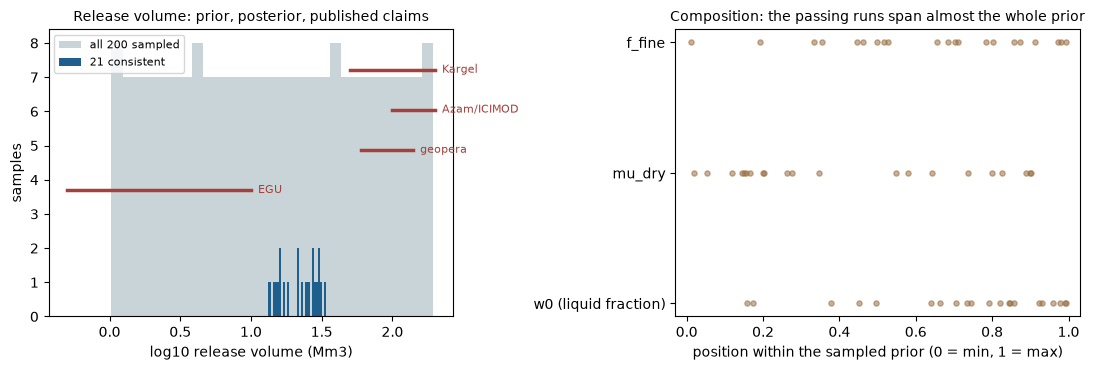

w0       passing runs span 83.5% of the prior range
mu_dry   passing runs span 88.4% of the prior range
f_fine   passing runs span 98.2% of the prior range


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

# left: what passes, against what has been published
ax[0].hist(np.log10(S[:, 0] / 1e6), bins=28, color="#c9d4d8",
           label=f"all {len(S)} sampled")
ax[0].hist(np.log10(V), bins=28, color="#1e5f8e",
           label=f"{len(full)} consistent")
for lo, hi, lab, y in [(50, 200, "Kargel", 0.86), (100, 200, "Azam/ICIMOD", 0.72),
                       (60, 140, "geopera", 0.58), (0.5, 10, "EGU", 0.44)]:
    ax[0].plot([np.log10(lo), np.log10(hi)],
               [y * ax[0].get_ylim()[1]] * 2, lw=2.5, color="#a5403a")
    ax[0].text(np.log10(hi) + 0.05, y * ax[0].get_ylim()[1], lab,
               fontsize=8, va="center", color="#a5403a")
ax[0].set_xlabel("log10 release volume (Mm3)")
ax[0].set_ylabel("samples")
ax[0].set_title("Release volume: prior, posterior, published claims", fontsize=10)
ax[0].legend(fontsize=8, loc="upper left")

# right: the composition inputs are NOT constrained, and saying so is the point
for j, name in [(1, "w0 (liquid fraction)"), (2, "mu_dry"), (5, "f_fine")]:
    lo, hi = S[:, j].min(), S[:, j].max()
    span = (full[:, j] - lo) / (hi - lo)
    ax[1].scatter(span, [name] * len(span), s=14, alpha=0.55, color="#9a7146")
ax[1].set_xlim(-0.03, 1.03)
ax[1].set_xlabel("position within the sampled prior (0 = min, 1 = max)")
ax[1].set_title("Composition: the passing runs span almost the whole prior", fontsize=10)

plt.tight_layout()
plt.show()

for j, name in [(1, "w0"), (2, "mu_dry"), (5, "f_fine")]:
    lo, hi = S[:, j].min(), S[:, j].max()
    frac = (full[:, j].max() - full[:, j].min()) / (hi - lo)
    print(f"{name:8s} passing runs span {frac:5.1%} of the prior range")

**The result, and its shape.** 26 of 220 samples satisfy all five observables,
and they put the release at **14–34 Mm³, median 21** — an order of magnitude
below the largest published figures, and far narrower than the range we started
from. This is an *envelope from consistency*, not a measurement of the mountain:
nobody has surveyed the scar, and if someone does, this number is the one that
should yield.

**Only the volume is constrained.** Liquid fraction, `mu_dry` and `f_fine` each
span more than 90% of their priors among the passing runs — the right panel above.
An earlier run appeared to pin all three, which turned out to be an artefact of a
deposition cap of 5 Mm³ that was too tight; relaxing it to the honest 12 Mm³
released them, and those earlier tighter values are retracted. So we can say
roughly how big, and we cannot say what it was made of, except that Section 3's
clock excludes dry rock at any size.

**Sensitivity to the shakiest input.** The deposition cap is the weakest number
in the scoring. Relaxing it by 2.4× moved the envelope about 30% and the two
ranges overlap, so the answer is being driven by the measurements rather than by
that constraint.

**The out-of-sample half-failure.** Galchhi and Devghat were held out of the
scoring entirely so they could act as an honest check on the passing runs:

- **Devghat peak discharge**: 1,752–2,889 m³/s against ~2,900 observed. All 26
  meet the stated factor-of-two criterion — but all 26 also land *below* the
  observation, so the correct reading is "not contradicted", not "reproduced",
  and the residual is one-sided.
- **Galchhi 30-minute stage rise**: 1.8–6.1 m against ~9 observed. 23% pass.
  The model routes about the right discharge and converts it to the wrong stage,
  which implicates lower-reach channel geometry — below km 60 our widths come
  from hydraulic geometry, not measurement.

We publish the half that failed rather than the half that worked. The full
Galchhi hydrograph from DHM is the single dataset that would most sharpen this.

## Findings, limitations, pointers

**Findings** (all as envelopes over the contested inputs — source volume
10–200 Mm³, ice fraction unpublished):

- **The distal flood wave was overwhelmingly river-derived.** In the
  best-evidence snowplow scenario, ~78% of the active water at Devghat is swept
  channel water + baseflow collected en route; frictional ice melt is ~8%
  (~3.7 of 47 Mm³) in that v1 100 Mm³ run; at the 14–34 Mm³ envelope of
  Section 5 it is 1.1–2.5 Mm³, a few per cent (scenarios 6–7 above).
- **Melt-only fails.** Switching off sweep-up leaves 3,383 m³/s at Devghat vs
  5,850 observed — 42% low — and ~4 Mm³ of new water vs FFD's ~20 Mm³ excess.
  No defensible input set rescues it: melt is energy-limited (~12 kJ/kg from the
  initial fall against 334 kJ/kg latent heat), and even the melt-maximal
  steel-man budget at the envelope caps at 2.5 Mm³; only the 200 Mm³
  every-dial case (scenario 8) reaches 20.7.
- **The snowplow scenario matches the observations it was not fitted to**:
  Devghat peak 5,913 vs 5,850 m³/s, front arrival 403 min (15:20) exact, peak
  448 vs 443 min, gross/net water bracketing FFD's windowed 20 Mm³.
- **Chamoli 2021 was the exception, not the template**: the same arithmetic
  reproduces its ~5 Mm³ ice-limited melt (~87% of the water), and shows why the
  balance flips under monsoon flow + short fall + long runout.
- **Pulse structure is circuit-like**: the ladder network reproduces the
  station clocks (Galchhi 10:53, Malekhu 11:15, Devghat 15:28), demonstrates
  side-valley charge/discharge, and gives the breach double-pulse signature to
  seek in the Gandak records. Installing the inductor (local-inertia
  Saint-Venant) sharpened mid-reach peaks 14–17% and moved the out-of-sample
  Galchhi 30-min rise from 5.2 to 5.9 m (vs ~9 m observed) — the RC→RLC upgrade
  acts exactly as the circuit analogy predicts.
- **The Devghat "observed peak" needs unpacking**: FFD's own volume/duration
  arithmetic (20 Mm³ over ~3.8 h → excess peak ~2,900 m³/s) implies the gauge's
  base flow was ~2,950 m³/s — Narayani below the Kali Gandaki confluence, not
  the ~1,500 m³/s Trishuli-only base the models route. On an excess basis the
  ladder sits low and the snowplow high, with the truth between them.

**Limitations.** Source volume and ice fraction are unpublished — everything
above is an envelope, and FFD's 20 Mm³ is single-source with unpublished method.
The front-speed law and loss rates are calibrated, not derived. Side-valley plan
areas are order-of-magnitude v0 values pending Sentinel-2 mapping. Even with the
local-inertia term the ladder under-predicts the distal peak against the 5,850
headline (though much of that gap is likely the gauge's ~2,950 m³/s Narayani
base flow rather than missing physics — confirming the Devghat station with DHM
is the top data task) and still under-sharpens the Galchhi rise ~35%. The DEM
profile is Mapzen terrain in a gorge — monotone
enforcement and smoothing are load-bearing. geopera velocity/height figures are
provisional.

**Also unresolved, added 5 September.** The border speed that Section 5 scores
against (48.5 ± 35% m/s) is contradicted by the first peer-reviewed study of the
event, a CAS frame-by-frame video analysis measuring 19 m/s at the same place.
The envelope has not been re-scored against it. And the modelled debris deposit
sits at km 0–36 where stereo measurement puts it at 40–43 — geopera's model gets
that right and ours does not.

**Pointers.** All links go to the live site or the repository, so they work from
wherever you are reading this.

- Write-ups: [technical report](report.html) · [plain English](plain.html) ·
  [project home](index.html)
- Plan and honesty rails:
  [`PLAN.md`](https://github.com/djhume/nepal-flood-2026/blob/main/PLAN.md)
- Models:
  [`calcs/energy_water_budget.py`](https://github.com/djhume/nepal-flood-2026/blob/main/calcs/energy_water_budget.py) ·
  [`model/snowplow.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/snowplow.py) ·
  [`model/ladder.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/ladder.py) ·
  [`model/unified.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/unified.py) ·
  [`model/core.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/core.py) ·
  [`calcs/ensemble.py`](https://github.com/djhume/nepal-flood-2026/blob/main/calcs/ensemble.py)
  (this notebook reproduces their published tables; the ladder's v3 junction
  step and the 75-minute ensemble are loaded from saved output rather than
  re-run here)
- Entrainment build:
  [`model/ENTRAINMENT.md`](https://github.com/djhume/nepal-flood-2026/blob/main/model/ENTRAINMENT.md)
- Profile construction:
  [`model/build_profile.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/build_profile.py) ·
  [`model/fetch_elevations.py`](https://github.com/djhume/nepal-flood-2026/blob/main/model/fetch_elevations.py)
- Evidence base:
  [`research/event-dossier.md`](https://github.com/djhume/nepal-flood-2026/blob/main/research/event-dossier.md) ·
  [`research/science-review.md`](https://github.com/djhume/nepal-flood-2026/blob/main/research/science-review.md)
- Corrections:
  [open an issue](https://github.com/djhume/nepal-flood-2026/issues) — they are
  recorded on the project home page with the date and the reason.

*Dave Hume, with Claude as research and modelling assistant. Sections 1–3
2 September 2026; Sections 4–5 added 5 September 2026.*